# Análisis Exploratorio de Datos (EDA) - Detección de Fake News en Español
## Proyecto: Fine-Tuning de Llama 3.2

Este cuaderno documenta el proceso de exploración, limpieza y unificación de las cuatro bases de datos utilizadas en el proyecto. El objetivo principal es construir un Dataset Maestro robusto y equilibrado.

### Puntos clave del procesamiento:
*   Normalización de Formatos: Unificación del formato de las diferentes bases de datos utilizadas.
*   Control de Longitud: Se establece un límite de 300 palabras por noticia. Esta es una decisión estrategica decidida a partir de la exploración de los datos, con esto se logra reducir el sesgo del modelo evitando que aprenda la relación noticia corta = falsa. Además esta decisión facilitara el manejo de los tokens para el entrenamiento con Llama 3.2.
*  Equilibrio de Clases: Creación de una base de datos final balanceada con 1,500 muestras por clase (Real vs. Fake), garantizando que el modelo no desarrolle favoritismos hacia ninguna etiqueta









Librerias


In [1]:
# 1. Sistema y Google Colab
import os
from google.colab import drive

# 2. Procesamiento de Datos y Computación Numérica
import pandas as pd
import numpy as np

# 3. Visualización de Datos
import matplotlib.pyplot as plt
import seaborn as sns

# 4. Procesamiento de Lenguaje Natural (NLP)
import spacy
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer

# Configuración opcional para visualización
%matplotlib inline
sns.set_theme(style="whitegrid")

Configuración del modelo, Carga de las Bases de Datos y Combinacion en un dataset Maestro





In [2]:
# Configuración del modelo
MODEL_ID = "meta-llama/Llama-3.2-3B-Instruct"

# URL Base para la carga de los datasets desde GitHub
GITHUB_BASE_URL = "https://raw.githubusercontent.com/Vasil255/Fine-Tuning_Llama-3.2_FakeNews/main/data/"
OUTPUT_FILE = "dataset_master_final.csv"

files = {
    "DF1 (Solo Fakes)": "esp_fake_news_3.xlsx",
    "DF2 (Corpus)":     "train_corpus.xlsx",
    "DF3 (Kaggle)":     "train_kaggle.xlsx",
    "DF4 (La Razón)":   "larazon.xlsx"
}

dataframes = {}
clean_dataframes = {}

# 1. CARGA DE TODOS LOS ARCHIVOS DESDE GITHUB
print("PASO 1: CARGANDO ARCHIVOS DESDE GITHUB REPOSITORY")

for name, filename in files.items():
    file_url = GITHUB_BASE_URL + filename

    print(f" -> Intentando leer {filename} desde GitHub...")
    try:
        if filename.endswith('.xlsx'):
            df = pd.read_excel(file_url)
        else:
            df = pd.read_csv(file_url, on_bad_lines='skip')

        dataframes[name] = df
        print(f" OK. Filas: {len(df)}")
        print(f" Columnas detectadas: {list(df.columns)}")
    except Exception as e:
        print(f" Error leyendo {filename}: {e}")
        print(f" Revisa que la URL sea correcta: {file_url}")


# 2. PROCESAMIENTO Y UNIFICACIÓN
print(" \n PASO 2: LIMPIEZA Y NORMALIZACIÓN")

def process_dataset(df_name, df_raw):
    print(f"Procesando: {df_name} ...")
    df = df_raw.copy()
    try:
        if "DF1" in df_name:
            df['text'] = df['Headlines'].fillna('').astype(str) + " . " + df['Fake statement'].fillna('').astype(str)
            df['label'] = 1
        elif "DF2" in df_name:
            df['text'] = df['Headline'].fillna('').astype(str) + " . " + df['Text'].fillna('').astype(str)
            map_dict = {'true': 0, 'fake': 1, 'True': 0, 'Fake': 1}
            df['label'] = df['Category'].astype(str).str.strip().map(map_dict)
        elif "DF3" in df_name:
            df['text'] = df['title'].fillna('').astype(str) + " . " + df['text'].fillna('').astype(str)
            df['label'] = pd.to_numeric(df['label'], errors='coerce')
        elif "DF4" in df_name:
            target_col = None
            for col in df.columns:
                if df[col].astype(str).str.len().mean() > 50:
                    target_col = col
                    break
            if target_col:
                df['text'] = df[target_col].astype(str)
                df['label'] = 0
            else: return None

        if 'label' not in df.columns or 'text' not in df.columns: return None

        df = df[['text', 'label']].dropna()
        df['label'] = df['label'].astype(int)
        df = df[df['text'].str.len() > 20]
        initial_len = len(df_raw)
        df = df.drop_duplicates(subset=['text'])
        print(f"      -> Filas finales: {len(df)} (Eliminados: {initial_len - len(df)})")
        return df
    except Exception as e:
        print(f"Error procesando {df_name}: {e}")
        return None

for name, df in dataframes.items():
    clean_df = process_dataset(name, df)
    if clean_df is not None:
        clean_dataframes[name] = clean_df


# 3. GUARDADO FINAL (En entorno local de Colab)
if clean_dataframes:
    dataset_master = pd.concat(clean_dataframes.values(), ignore_index=True)
    dataset_master = dataset_master.sample(frac=1, random_state=42).reset_index(drop=True)

    print(f"\n DATASET MAESTRO GENERADO: {len(dataset_master)} noticias.")
    print(dataset_master['label'].value_counts())

    # Lo guardamos en el almacenamiento temporal de la sesión (carpeta /content)
    dataset_master.to_csv(OUTPUT_FILE, index=False)
    print(f" Archivo guardado localmente como: {OUTPUT_FILE}")
else:
    print(" Error: No se ha podido generar ningún dato válido.")

PASO 1: CARGANDO ARCHIVOS DESDE GITHUB REPOSITORY
 -> Intentando leer esp_fake_news_3.xlsx desde GitHub...
 OK. Filas: 2552
 Columnas detectadas: ['Headlines', 'Fake statement']
 -> Intentando leer train_corpus.xlsx desde GitHub...
 OK. Filas: 676
 Columnas detectadas: ['Category', 'Headline', 'Text']
 -> Intentando leer train_kaggle.xlsx desde GitHub...
 OK. Filas: 1600
 Columnas detectadas: ['title', 'text', 'label']
 -> Intentando leer larazon.xlsx desde GitHub...
 OK. Filas: 1218
 Columnas detectadas: ['Column2']
 
 PASO 2: LIMPIEZA Y NORMALIZACIÓN
Procesando: DF1 (Solo Fakes) ...
      -> Filas finales: 2518 (Eliminados: 34)
Procesando: DF2 (Corpus) ...
      -> Filas finales: 676 (Eliminados: 0)
Procesando: DF3 (Kaggle) ...
      -> Filas finales: 1587 (Eliminados: 13)
Procesando: DF4 (La Razón) ...
      -> Filas finales: 1137 (Eliminados: 81)

 DATASET MAESTRO GENERADO: 5918 noticias.
label
1    3646
0    2272
Name: count, dtype: int64
 Archivo guardado localmente como: dataset

Visualización de la distribución de clases

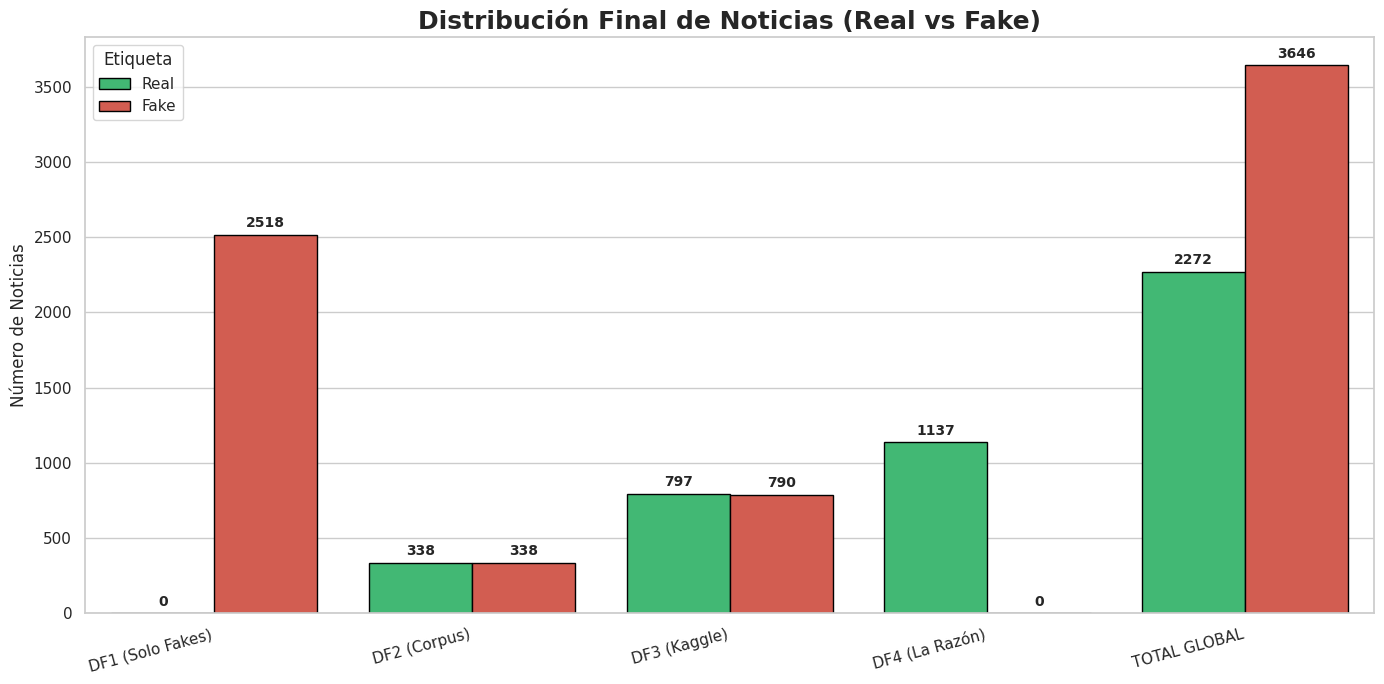

ANÁLISIS DE BALANCE PARA ENTRENAMIENTO
Total Real: 2272
Total Fake: 3646
Total Muestras: 5918
Ratio actual: 1 noticia Real por cada 1.60 Falsas


In [3]:
# Verificación de seguridad: ¿Existe la variable con los datos limpios?
if 'clean_dataframes' not in globals() or not clean_dataframes:
    print(" Error: No se encuentra la variable 'clean_dataframes'. Asegúrate de haber ejecutado con éxito el bloque anterior (Carga y Limpieza).")
else:
    # 1. PREPARAR DATOS PARA EL GRÁFICO
    stats_list = []

    for name in sorted(clean_dataframes.keys()):
        df = clean_dataframes[name]
        counts = df['label'].value_counts()

        # .get(0, 0) evita errores si un dataset solo tiene una clase
        real_count = counts.get(0, 0)
        fake_count = counts.get(1, 0)

        stats_list.append({"Dataset": name, "Clase": "Real", "Cantidad": real_count})
        stats_list.append({"Dataset": name, "Clase": "Fake", "Cantidad": fake_count})

    # Calcular el TOTAL COMBINADO
    total_real = sum(d['Cantidad'] for d in stats_list if d['Clase'] == 'Real')
    total_fake = sum(d['Cantidad'] for d in stats_list if d['Clase'] == 'Fake')

    # Añadimos el Total al final
    stats_list.append({"Dataset": "TOTAL GLOBAL", "Clase": "Real", "Cantidad": total_real})
    stats_list.append({"Dataset": "TOTAL GLOBAL", "Clase": "Fake", "Cantidad": total_fake})

    df_stats = pd.DataFrame(stats_list)

    # 2. GENERAR GRÁFICO
    plt.figure(figsize=(14, 7))
    sns.set_theme(style="whitegrid")
    colores = {"Real": "#2ecc71", "Fake": "#e74c3c"}
    ax = sns.barplot(
        data=df_stats,
        x="Dataset",
        y="Cantidad",
        hue="Clase",
        palette=colores,
        edgecolor="black"
    )

    # Etiquetas y Títulos
    plt.title("Distribución Final de Noticias (Real vs Fake)", fontsize=18, fontweight='bold')
    plt.xlabel("", fontsize=12)
    plt.ylabel("Número de Noticias", fontsize=12)
    plt.legend(title="Etiqueta")
    plt.xticks(rotation=15, ha='right')
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', padding=3, fontweight='bold', fontsize=10)

    plt.tight_layout()
    plt.show()

    # 3. RESUMEN NUMÉRICO Y RATIO
    print(f"ANÁLISIS DE BALANCE PARA ENTRENAMIENTO")
    print(f"Total Real: {total_real}")
    print(f"Total Fake: {total_fake}")
    print(f"Total Muestras: {total_real + total_fake}")

    if total_real > 0:
        ratio = total_fake / total_real
        print(f"Ratio actual: 1 noticia Real por cada {ratio:.2f} Falsas")
    else:
        print("¡ERROR CRÍTICO! No tienes noticias REALES. Revisa la carga de La Razón.")

Visualización longitud media

,Media Actual,Mediana,Máximo,% Afectadas (>300)
Dataset,,,,
DF1 (Solo Fakes),92.8,41.0,1506.0,7.0
DF2 (Corpus),390.2,326.5,2095.0,56.2
DF3 (Kaggle),50.5,53.0,387.0,0.1
DF4 (La Razón),526.4,454.0,2964.0,70.5


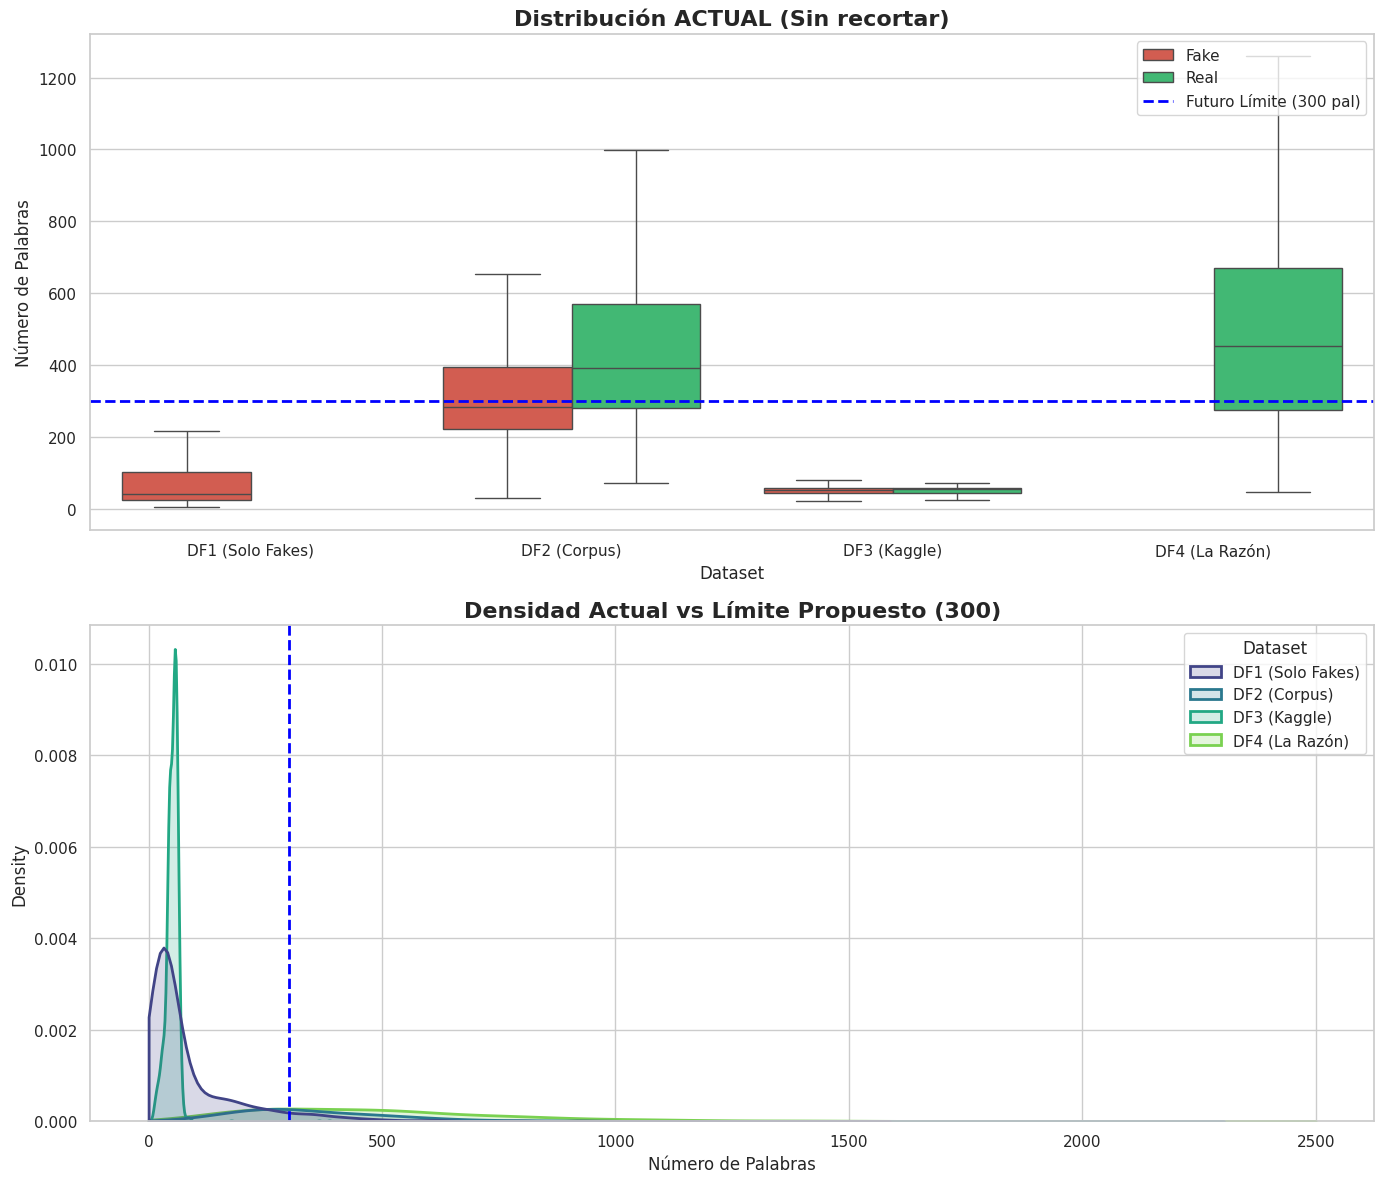

In [7]:
# configuración
sns.set_theme(style="whitegrid")
MAX_WORDS = 300  # <--- Para DIBUJAR la línea
# Verificación de seguridad
if 'clean_dataframes' not in globals() or not clean_dataframes:
    print("Error: No se encuentra la variable 'clean_dataframes'.")
else:
    all_lengths_data = []
    stats_summary = []
    # Iteramos sobre los datasets originales
    for name, df in sorted(clean_dataframes.items()):

        # 1. Calcular longitud actual
        lengths = df['text'].astype(str).apply(lambda x: len(x.split()))

        # 2. Guardar datos para gráficos
        temp_df = pd.DataFrame({
            'Dataset': name,
            'Num_Palabras': lengths,
            'Label': df['label'].map({0: 'Real', 1: 'Fake'})
        })
        all_lengths_data.append(temp_df)

        # 3. Calcular Estadísticas y % de afectación
        desc = lengths.describe()
        n_afectadas = sum(lengths > MAX_WORDS)
        pct_afectadas = (n_afectadas / len(lengths)) * 100

        stats_summary.append({
            "Dataset": name,
            "Media Actual": desc['mean'],
            "Mediana": desc['50%'],
            "Máximo": desc['max'],
            "% Afectadas (>300)": pct_afectadas
        })

    # 1. MOSTRAR TABLA DE IMPACTO
    df_stats = pd.DataFrame(stats_summary).set_index("Dataset")
    pd.options.display.float_format = '{:.1f}'.format

    display(df_stats)

    # 2. VISUALIZACIÓN
    df_plot = pd.concat(all_lengths_data)

    fig, axes = plt.subplots(2, 1, figsize=(14, 12))

    # A. BOXPLOT (Cajas)
    sns.boxplot(
        data=df_plot,
        x="Dataset",
        y="Num_Palabras",
        hue="Label",
        ax=axes[0],
        palette={"Real": "#2ecc71", "Fake": "#e74c3c"},
        showfliers=False
    )
    axes[0].set_title("Distribución ACTUAL (Sin recortar)", fontsize=16, fontweight='bold')
    axes[0].axhline(y=MAX_WORDS, color='blue', linestyle='--', linewidth=2, label=f'Futuro Límite ({MAX_WORDS} pal)')
    axes[0].set_ylabel("Número de Palabras")
    axes[0].legend(loc='upper right')

    # B. KDE (Densidad)
    sns.kdeplot(
        data=df_plot,
        x="Num_Palabras",
        hue="Dataset",
        fill=True,
        alpha=0.2,
        ax=axes[1],
        palette="viridis",
        linewidth=2,
        clip=(0, 2500)
    )
    axes[1].set_title(f"Densidad Actual vs Límite Propuesto ({MAX_WORDS})", fontsize=16, fontweight='bold')
    axes[1].axvline(x=MAX_WORDS, color='blue', linestyle='--', linewidth=2, label='Punto de Corte')
    axes[1].set_xlabel("Número de Palabras")

    plt.tight_layout()
    plt.show()


Visualización post truncado en 300 palabras

EJECUTANDO RECORTE REAL A 300 PALABRAS...
   Processing DF1 (Solo Fakes)...
   Processing DF2 (Corpus)...
   Processing DF3 (Kaggle)...
   Processing DF4 (La Razón)...
Dataset Maestro actualizado y barajado (Total: 5918 filas).


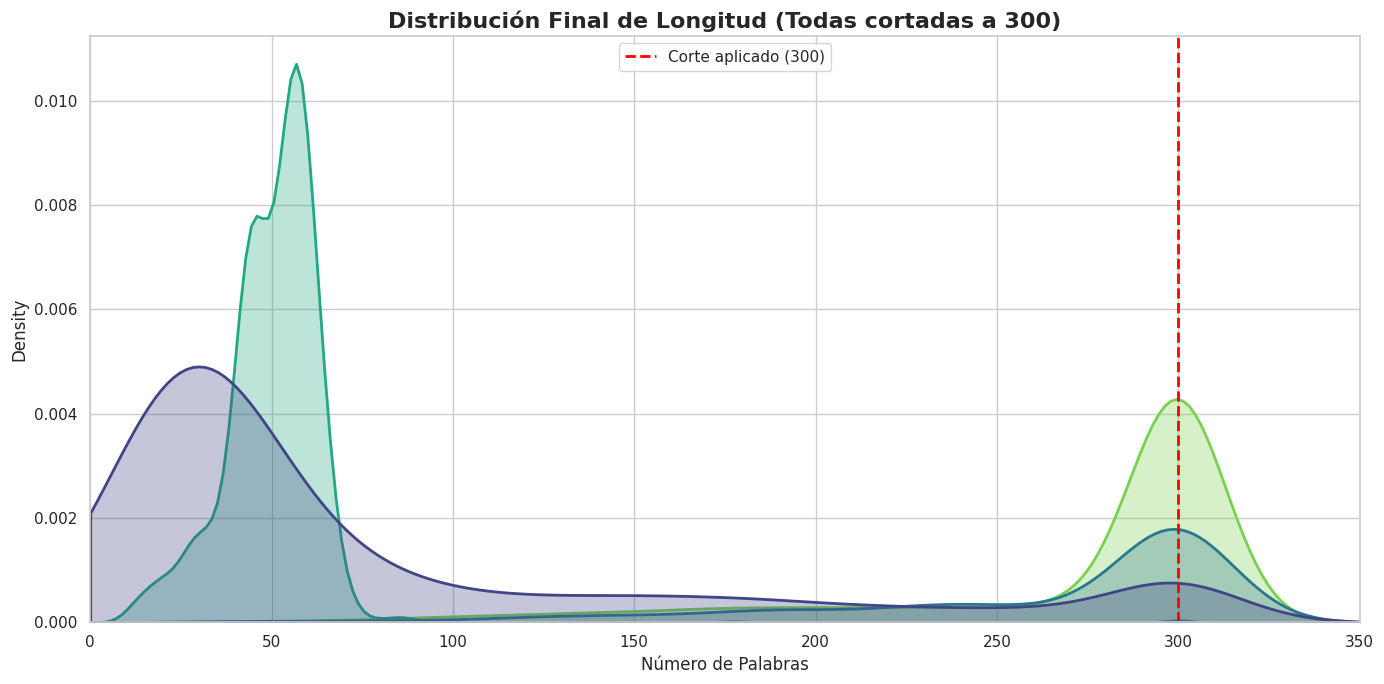

In [8]:
# configuración
MAX_WORDS = 300
sns.set_theme(style="whitegrid")

if 'clean_dataframes' not in globals() or not clean_dataframes:
    print("Error: No se encuentra la variable 'clean_dataframes'.")
else:
    print(f"EJECUTANDO RECORTE REAL A {MAX_WORDS} PALABRAS...")

    # 1. FUNCIÓN DE RECORTE
    def smart_truncate(text, limit):
        words = str(text).split()
        if len(words) > limit:
            return " ".join(words[:limit])
        return str(text)

    # 2. MODIFICAMOS LOS DATOS EN MEMORIA
    for name in clean_dataframes:
        print(f"   Processing {name}...")
        clean_dataframes[name]['text'] = clean_dataframes[name]['text'].apply(lambda x: smart_truncate(x, MAX_WORDS))

    # 3. REGENERAMOS EL DATASET MAESTRO
    dataset_master = pd.concat(clean_dataframes.values(), ignore_index=True)
    dataset_master = dataset_master.sample(frac=1, random_state=42).reset_index(drop=True)
    print(f"Dataset Maestro actualizado y barajado (Total: {len(dataset_master)} filas).")

    # 4. PREPARAR DATOS PARA EL GRÁFICO
    all_lengths_data = []
    for name, df in clean_dataframes.items():
        temp_df = pd.DataFrame({
            'Dataset': name,
            'Num_Palabras': df['text'].apply(lambda x: len(str(x).split()))
        })
        all_lengths_data.append(temp_df)

    df_plot = pd.concat(all_lengths_data)

    # 5. GRÁFICO DE DENSIDAD
    plt.figure(figsize=(14, 7))

    sns.kdeplot(
        data=df_plot,
        x="Num_Palabras",
        hue="Dataset",
        fill=True,
        alpha=0.3,
        palette="viridis",
        linewidth=2,
        clip=(0, MAX_WORDS + 50)
    )

    plt.axvline(x=MAX_WORDS, color='red', linestyle='--', linewidth=2, label=f'Corte aplicado ({MAX_WORDS})')
    plt.title(f"Distribución Final de Longitud (Todas cortadas a {MAX_WORDS})", fontsize=16, fontweight='bold')
    plt.xlabel("Número de Palabras")
    plt.xlim(0, MAX_WORDS + 50)
    plt.legend()
    plt.tight_layout()
    plt.show()


Visualización NGramas

Analizando patrones en: DF1 (Solo Fakes)...


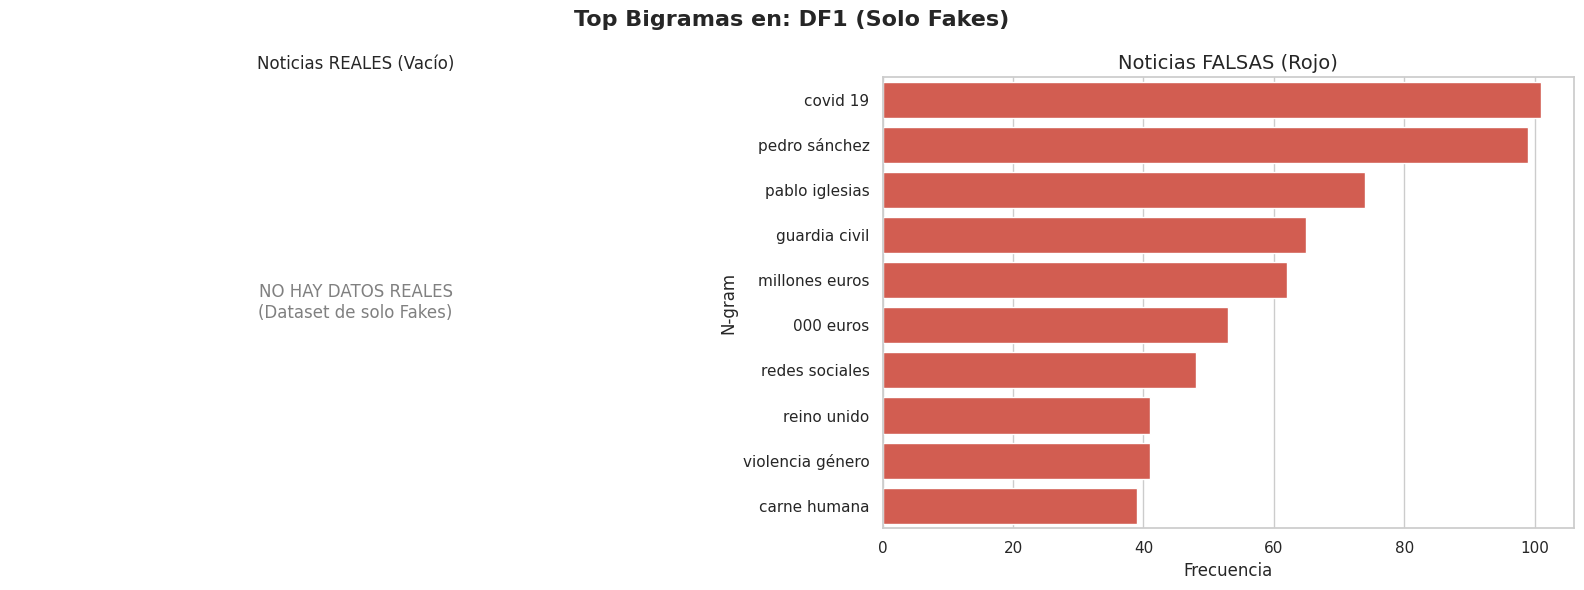

Analizando patrones en: DF2 (Corpus)...


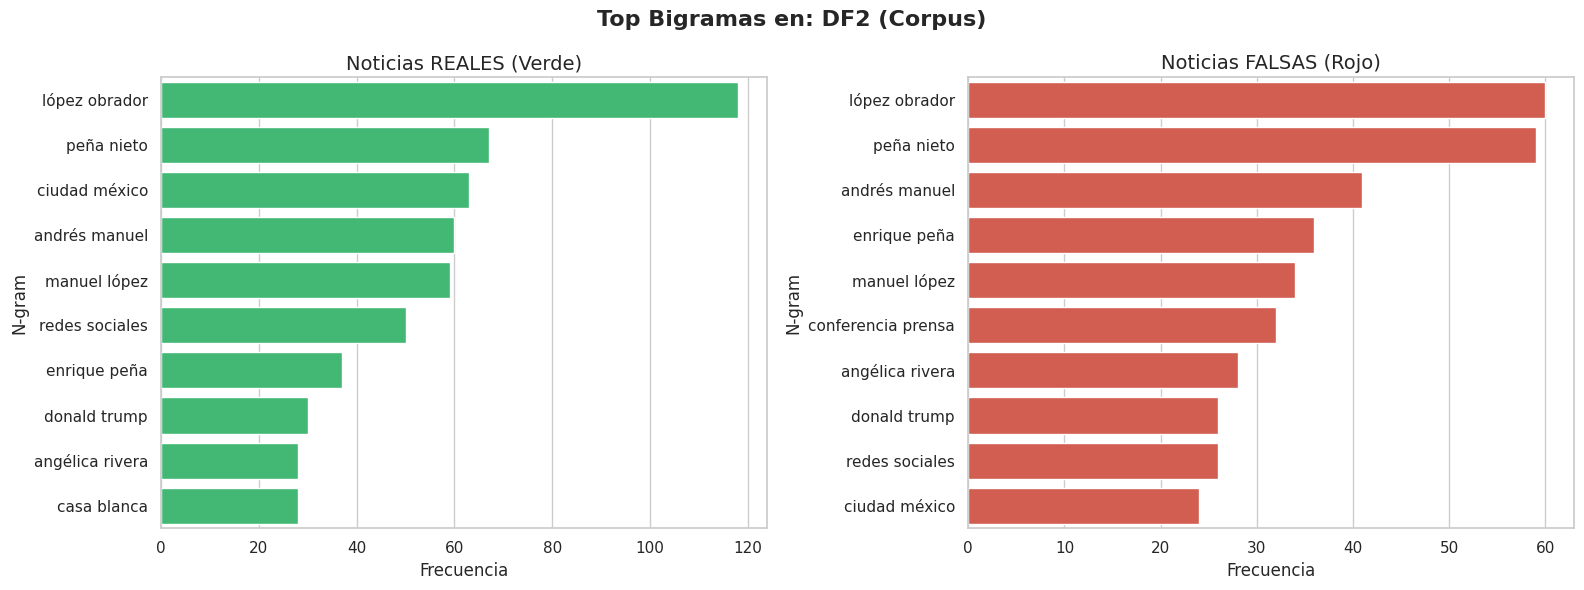

Analizando patrones en: DF3 (Kaggle)...


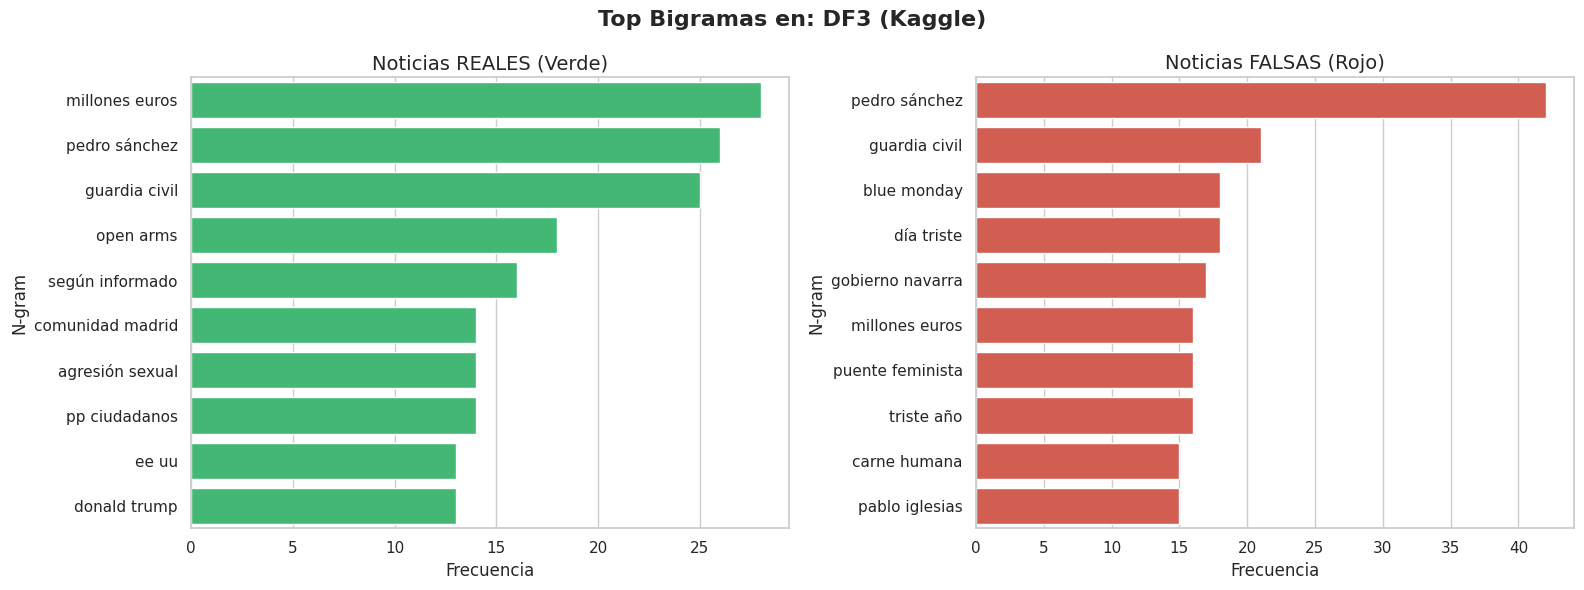

Analizando patrones en: DF4 (La Razón)...


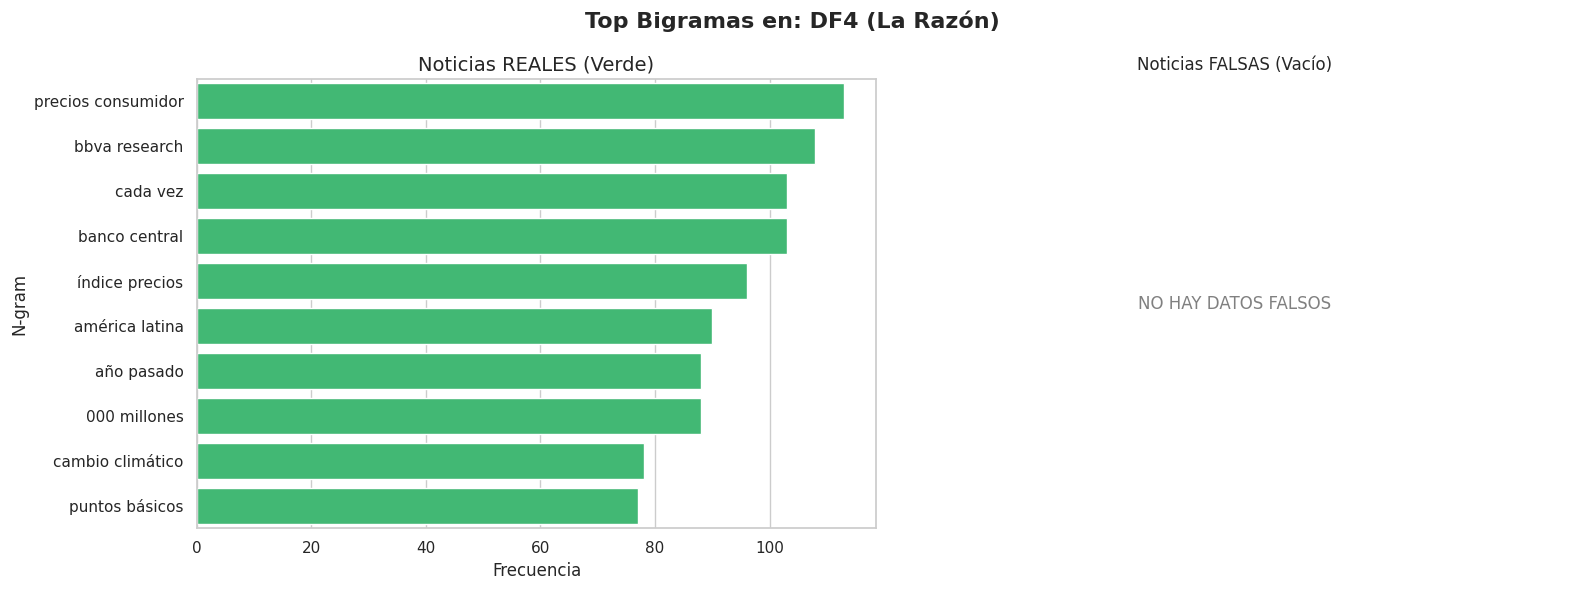

In [9]:
# 1. CONFIGURACIÓN DE STOPWORDS (Palabras a ignorar)
# Descargamos las listas
nltk.download('stopwords', quiet=True)
stop_es = stopwords.words('spanish')
stop_en = stopwords.words('english')

# Palabras basura específicas detectadas en estos datasets
custom_stops = [
    'si', 'ser', 'hace', 'solo', 'después', 'dice', 'tan', 'va', 't', 'co',
    'https', 'http', 'com', 'www', 'image', 'video', 'twitter', 'pic',
    'number', '*number*', 'num', 'cifra', 'cantidad',
    'la', 'el', 'los', 'las', 'un', 'una', 'y', 'de', 'en'
]

final_stop_words = stop_es + stop_en + custom_stops

# 2. FUNCIÓN PARA OBTENER TOP N-GRAMS
def get_top_ngrams(corpus, n=2, top_k=10):
    """
    Extrae las parejas (n=2) o tríos (n=3) de palabras más comunes.
    Maneja errores si el corpus es muy pequeño.
    """
    try:
        # stop_words acepta una lista. Al ser mixta (En/Es), filtrará en ambos idiomas.
        vec = CountVectorizer(ngram_range=(n, n), stop_words=final_stop_words).fit(corpus)
        bag_of_words = vec.transform(corpus)
        sum_words = bag_of_words.sum(axis=0)
        words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
        words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
        return words_freq[:top_k]
    except ValueError:
        return []
    except Exception as e:
        print(f"Error inesperado en vectorización: {e}")
        return []

# 3. FUNCIÓN DE VISUALIZACIÓN ROBUSTA
def plot_ngrams_comparison(df_name, df, n_gram=2):
    print(f"Analizando patrones en: {df_name}...")

    # Separar Real (0) y Fake (1) asegurando que sean strings
    df_real = df[df['label'] == 0]['text'].astype(str)
    df_fake = df[df['label'] == 1]['text'].astype(str)

    # Listas para resultados
    top_real = []
    top_fake = []

    # Intentar extraer SOLO si hay datos en esa categoría
    if len(df_real) > 0:
        top_real = get_top_ngrams(df_real, n=n_gram, top_k=10)

    if len(df_fake) > 0:
        top_fake = get_top_ngrams(df_fake, n=n_gram, top_k=10)

    # Si no hay nada de nada, avisar y saltar
    if not top_real and not top_fake:
        print(f"Saltando {df_name}: No hay texto suficiente.")
        return

    # CONFIGURACIÓN DEL PLOT
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    tipo = "Bigramas" if n_gram == 2 else "Trigramas"
    fig.suptitle(f"Top {tipo} en: {df_name}", fontsize=16, fontweight='bold')

    # GRÁFICO IZQUIERDA: REALES
    if top_real:
        df_plot_real = pd.DataFrame(top_real, columns=['N-gram', 'Frecuencia'])
        sns.barplot(ax=axes[0], x='Frecuencia', y='N-gram', data=df_plot_real, color='#2ecc71')
        axes[0].set_title(f"Noticias REALES (Verde)", fontsize=14)
        axes[0].set_xlabel("Frecuencia")
    else:
        # Si está vacío (caso DF1), ponemos un aviso visual
        axes[0].text(0.5, 0.5, "NO HAY DATOS REALES\n(Dataset de solo Fakes)", ha='center', va='center', fontsize=12, color='gray')
        axes[0].set_title("Noticias REALES (Vacío)")
        axes[0].set_axis_off()

    # GRÁFICO DERECHA: FAKES
    if top_fake:
        df_plot_fake = pd.DataFrame(top_fake, columns=['N-gram', 'Frecuencia'])
        sns.barplot(ax=axes[1], x='Frecuencia', y='N-gram', data=df_plot_fake, color='#e74c3c')
        axes[1].set_title(f"Noticias FALSAS (Rojo)", fontsize=14)
        axes[1].set_xlabel("Frecuencia")
    else:
        axes[1].text(0.5, 0.5, "NO HAY DATOS FALSOS", ha='center', va='center', fontsize=12, color='gray')
        axes[1].set_title("Noticias FALSAS (Vacío)")
        axes[1].set_axis_off()

    plt.tight_layout()
    plt.show()

# 4. EJECUCIÓN

if 'clean_dataframes' in globals() and clean_dataframes:
    for name, df in sorted(clean_dataframes.items()):
        plot_ngrams_comparison(name, df, n_gram=2)
else:
    print("ERROR: No encuentro la variable 'clean_dataframes'.")

ANÁLISIS GRAMATICAL (Adjetivos, Verbos, Sustantivos)

Analizando gramática de: DF1 (Solo Fakes) (puede tardar un poco)...
Analizando gramática de: DF2 (Corpus) (puede tardar un poco)...
Analizando gramática de: DF3 (Kaggle) (puede tardar un poco)...
Analizando gramática de: DF4 (La Razón) (puede tardar un poco)...


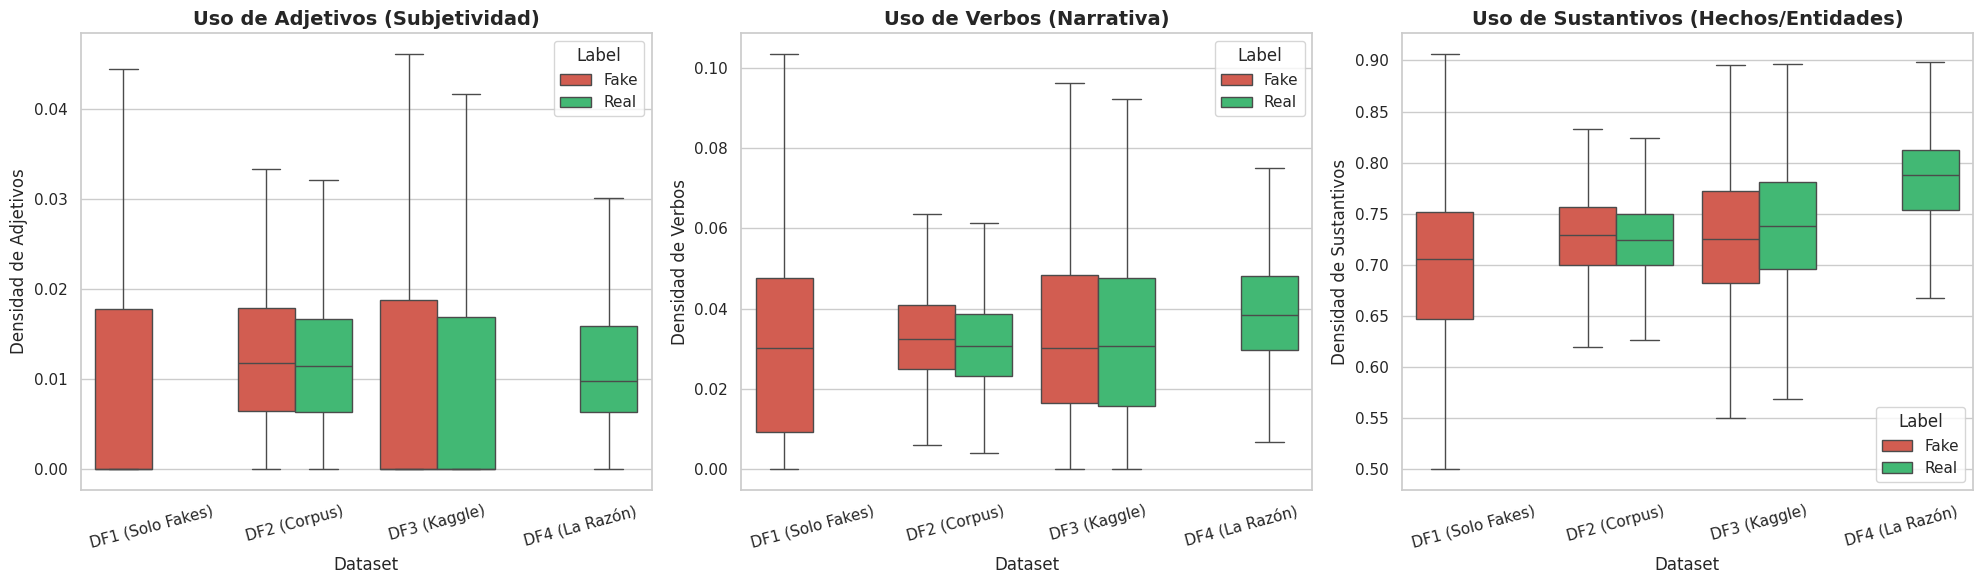


 MEDIAS GRAMATICALES:


Adj_Ratio  Verb_Ratio  Noun_Ratio
Dataset          Label                                   
DF1 (Solo Fakes) Fake      0.0112      0.0332      0.6945
DF2 (Corpus)     Fake      0.0133      0.0345      0.7263
                 Real      0.0123      0.0312      0.7228
DF3 (Kaggle)     Fake      0.0115      0.0328      0.7238
                 Real      0.0100      0.0327      0.7366
DF4 (La Razón)   Real      0.0115      0.0392      0.7812

In [11]:
# configuración
sns.set_theme(style="whitegrid")

# Cargamos el modelo de NLP (Español)
import en_core_web_sm
nlp = en_core_web_sm.load()

# FUNCIÓN DE EXTRACCIÓN GRAMATICAL
def extract_grammar_features(text):
    if not isinstance(text, str) or len(text) == 0:
        return pd.Series([0, 0, 0])

    # Procesamos el texto con spaCy (tokenización y tagging)
    # Desactivamos NER y Parser para ir más rápido (solo queremos TAGs)
    doc = nlp(text, disable=["ner", "parser"])

    num_tokens = len(doc)
    if num_tokens == 0:
        return pd.Series([0, 0, 0])

    # 1. Densidad de Adjetivos (Indicador de Subjetividad/Emoción)
    n_adj = sum(1 for token in doc if token.pos_ == 'ADJ')

    # 2. Densidad de Verbos (Indicador de Narrativa/Acción)
    n_verb = sum(1 for token in doc if token.pos_ == 'VERB')

    # 3. Densidad de Sustantivos (Indicador de Carga Informativa)
    n_noun = sum(1 for token in doc if token.pos_ == 'NOUN' or token.pos_ == 'PROPN')

    # Retornamos ratios (porcentaje del texto que son adjetivos, verbos, etc.)
    return pd.Series([n_adj/num_tokens, n_verb/num_tokens, n_noun/num_tokens])

# PROCESAMIENTO
if 'clean_dataframes' not in globals() or not clean_dataframes:
    print("Error: No se encuentra la variable 'clean_dataframes'.")
else:
    all_grammar_data = []

    for name, df in sorted(clean_dataframes.items()):
        print(f"Analizando gramática de: {name} (puede tardar un poco)...")

        df_sample = df.copy()
        if len(df_sample) > 5000:
            df_sample = df_sample.sample(5000, random_state=42)

        features = df_sample['text'].apply(extract_grammar_features)
        features.columns = ['Adj_Ratio', 'Verb_Ratio', 'Noun_Ratio']

        features['Dataset'] = name
        features['Label'] = df_sample['label'].map({0: 'Real', 1: 'Fake'})

        all_grammar_data.append(features)

    # Unimos todo
    df_grammar = pd.concat(all_grammar_data)

    # VISUALIZACIÓN
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    colors = {"Real": "#2ecc71", "Fake": "#e74c3c"} # Verde y Rojo

    # Gráfico 1: Adjetivos (Subjetividad)
    sns.boxplot(ax=axes[0], x="Dataset", y="Adj_Ratio", hue="Label", data=df_grammar, palette=colors, showfliers=False)
    axes[0].set_title("Uso de Adjetivos (Subjetividad)", fontsize=14, fontweight='bold')
    axes[0].set_ylabel("Densidad de Adjetivos")
    axes[0].tick_params(axis='x', rotation=15)

    # Gráfico 2: Verbos (Acción)
    sns.boxplot(ax=axes[1], x="Dataset", y="Verb_Ratio", hue="Label", data=df_grammar, palette=colors, showfliers=False)
    axes[1].set_title("Uso de Verbos (Narrativa)", fontsize=14, fontweight='bold')
    axes[1].set_ylabel("Densidad de Verbos")
    axes[1].tick_params(axis='x', rotation=15)

    # Gráfico 3: Sustantivos (Información)
    sns.boxplot(ax=axes[2], x="Dataset", y="Noun_Ratio", hue="Label", data=df_grammar, palette=colors, showfliers=False)
    axes[2].set_title("Uso de Sustantivos (Hechos/Entidades)", fontsize=14, fontweight='bold')
    axes[2].set_ylabel("Densidad de Sustantivos")
    axes[2].tick_params(axis='x', rotation=15)

    plt.tight_layout()
    plt.show()

    # TABLA RESUMEN
    print("\n MEDIAS GRAMATICALES:")
    means = df_grammar.groupby(['Dataset', 'Label'])[['Adj_Ratio', 'Verb_Ratio', 'Noun_Ratio']].mean()
    pd.options.display.float_format = '{:.4f}'.format
    display(means)

Recorte y guardado de la base de datos

In [12]:
# configuración
TARGET_SAMPLES = 1500  #LÍMITE: 1500 para Reales y 1500 para Fakes
OUTPUT_FILE_BALANCED = "dataset_master_balanced.csv"

if 'clean_dataframes' not in globals() or not clean_dataframes:
    print("Error: No se encuentra 'clean_dataframes'. Ejecuta el bloque de carga primero.")
else:
    # 1. Unificar todos los dataframes
    full_pool = pd.concat(clean_dataframes.values(), ignore_index=True)

    # 2. Separar por clases
    df_reals_pool = full_pool[full_pool['label'] == 0]
    df_fakes_pool = full_pool[full_pool['label'] == 1]

    count_reals = len(df_reals_pool)
    count_fakes = len(df_fakes_pool)

    print(f"   - Total Reales disponibles: {count_reals}")
    print(f"   - Total Fakes disponibles:  {count_fakes}")

    # 3. Selección de datos (Aplicamos el recorte a AMBAS clases)

    # A. REALES
    if count_reals > TARGET_SAMPLES:
        df_final_reals = df_reals_pool.sample(n=TARGET_SAMPLES, random_state=42)
    else:
        df_final_reals = df_reals_pool.copy()

    # B. FAKES
    if count_fakes > TARGET_SAMPLES:
        df_final_fakes = df_fakes_pool.sample(n=TARGET_SAMPLES, random_state=42)
    else:
        df_final_fakes = df_fakes_pool.copy()

    # 4. Crear Dataset Final
    dataset_balanced = pd.concat([df_final_reals, df_final_fakes], ignore_index=True)

    # 5. Shuffle Final (Mezclar todo)
    dataset_balanced = dataset_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

    # RESULTADOS
    print("Distribución Final:")
    dist = dataset_balanced['label'].value_counts()
    print(dist)

    # Guardar
    if 'FOLDER_PATH' in globals():
        out_path = os.path.join(FOLDER_PATH, OUTPUT_FILE_BALANCED)
    else:
        out_path = OUTPUT_FILE_BALANCED

    dataset_balanced.to_csv(out_path, index=False)
    print(f"Guardado en: {out_path}")

   - Total Reales disponibles: 2272
   - Total Fakes disponibles:  3646
Distribución Final:
label
1    1500
0    1500
Name: count, dtype: int64
Guardado en: dataset_master_balanced.csv


Mas visualización y calculo tokens para llama 3.2

ESTADÍSTICAS DE LONGITUD (Dataset Balanceado)


char_count                        word_count                      
            mean median min   max   std       mean median min  max   std
label                                                                   
Real      1197.9 1595.0  66  2113 708.9      195.5  261.5  11  300 113.9
Fake       522.9  272.5  29  1965 542.4       88.6   48.0   6  300  90.5

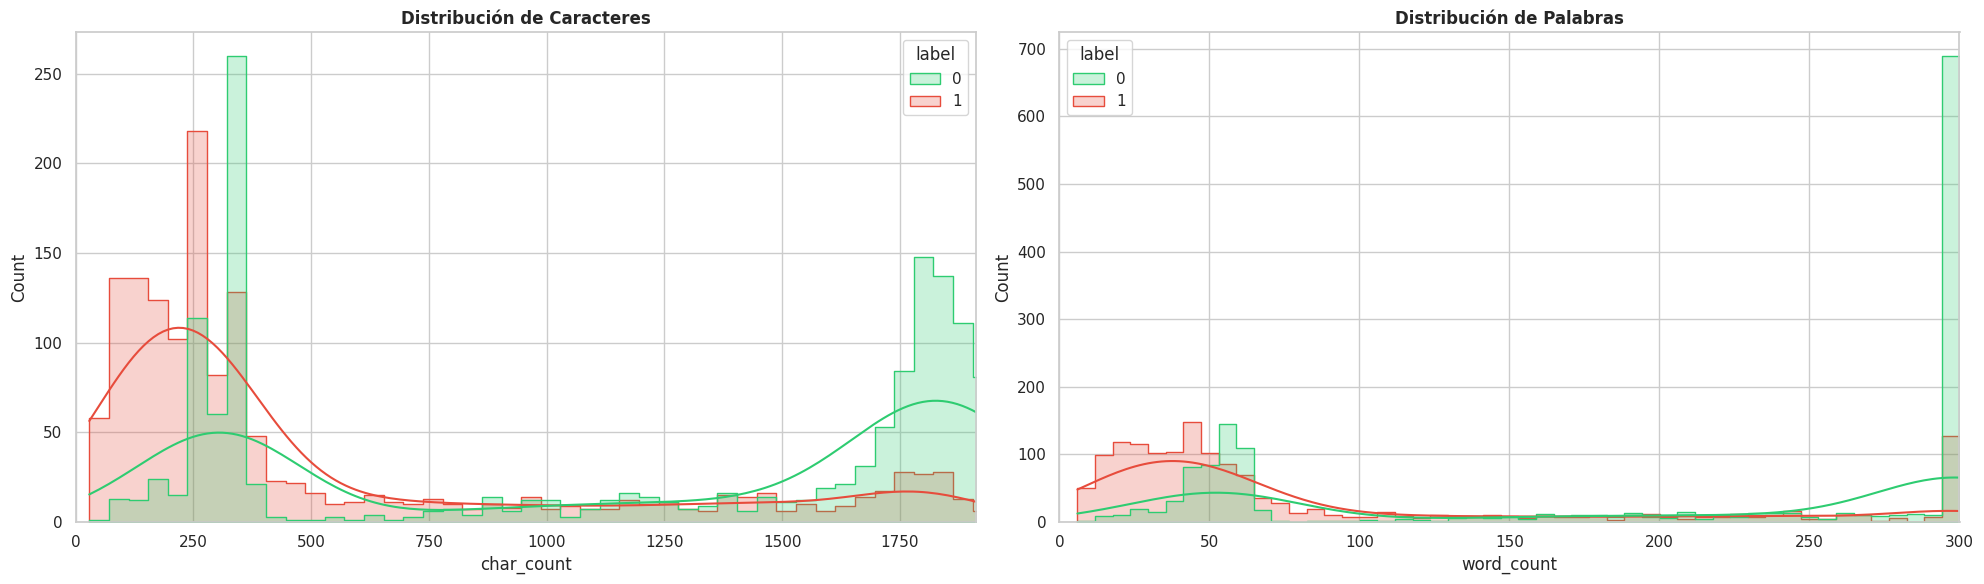

   - Longitud media estimada: ~184 tokens.


In [14]:
# configuración
sns.set_theme(style="whitegrid")

if 'dataset_balanced' not in globals():
    print("Error: No se encuentra 'dataset_balanced'. Ejecuta el paso anterior.")
else:
    df_len = dataset_balanced.copy()

    # 1. Calculamos longitudes
    # Longitud en Caracteres
    df_len['char_count'] = df_len['text'].astype(str).apply(len)

    # Longitud estimada en Palabras (aprox tokens = palabras * 1.3)
    df_len['word_count'] = df_len['text'].astype(str).apply(lambda x: len(x.split()))

    # 2. Estadísticas Generales
    print("ESTADÍSTICAS DE LONGITUD (Dataset Balanceado)")


    # Tabla resumen por etiqueta
    summary = df_len.groupby('label')[['char_count', 'word_count']].agg(['mean', 'median', 'min', 'max', 'std'])

    # Renombrar índices para que se entienda
    summary.index = summary.index.map({0: 'Real', 1: 'Fake'})

    # Mostrar tabla
    pd.options.display.float_format = '{:.1f}'.format
    display(summary)

    # 3. Visualización (Histogramas superpuestos)
    fig, axes = plt.subplots(1, 2, figsize=(20, 6))

    # Gráfico Caracteres
    sns.histplot(data=df_len, x='char_count', hue='label', kde=True, element="step",
                 bins=50, palette={0: "#2ecc71", 1: "#e74c3c"}, ax=axes[0])
    axes[0].set_title('Distribución de Caracteres', fontweight='bold')
    axes[0].set_xlim(0, df_len['char_count'].quantile(0.95)) # Cortamos el 5% más largo para ver mejor el grueso

    # Gráfico Palabras
    sns.histplot(data=df_len, x='word_count', hue='label', kde=True, element="step",
                 bins=50, palette={0: "#2ecc71", 1: "#e74c3c"}, ax=axes[1])
    axes[1].set_title('Distribución de Palabras', fontweight='bold')
    axes[1].set_xlim(0, df_len['word_count'].quantile(0.95))

    plt.tight_layout()
    plt.show()

    # RECOMENDACIÓN PARA LLAMA 3
    avg_words = df_len['word_count'].mean()
    # Estimación: 1 palabra ≈ 1.3 tokens en Llama 3
    est_tokens = avg_words * 1.3

    print(f"   - Longitud media estimada: ~{int(est_tokens)} tokens.")